对于 $y=f(x)$, 梯度的物理意义：在当前 x 的值，微微扰动 x，y 的变化率（斜率） 

In [1]:
class Value:
    def __init__(self, data, _children=(), _op='', label=None):
        self.data = data
        self._op = _op
        self._prev = set(_children)
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value data:{self.data}"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self,other), _op='+')

        def _backward():        
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self,other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    if child not in visited:
                        build_topo(child)
                    topo.append(v)
            return topo
        build_topo(self)
        
        self.grad = 1.0
        
        for node in reversed(topo):
            node._backward()



In [2]:
from graphviz import Digraph

def trace(root):
    # build a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid) # 因为遍历的时候从根节点开始，所以这里是从 op 指向 uid
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


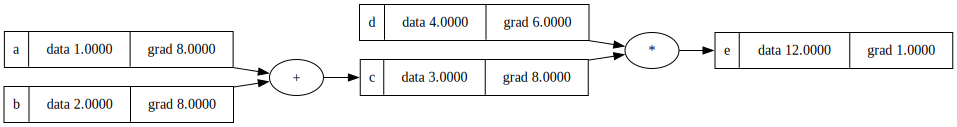

In [3]:
a = Value(1.0, label='a')
b = Value(2.0, label='b')
c = a + b; c.label='c'
d = Value(4.0, label='d')
e = c * d; e.label='e'

e.backward()

draw_dot(e)

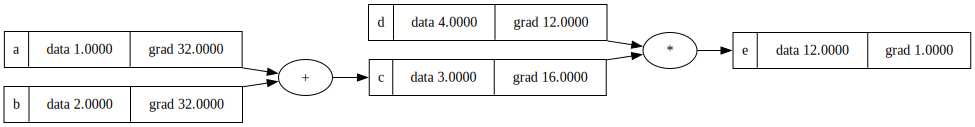

In [4]:
e.backward()
draw_dot(e)

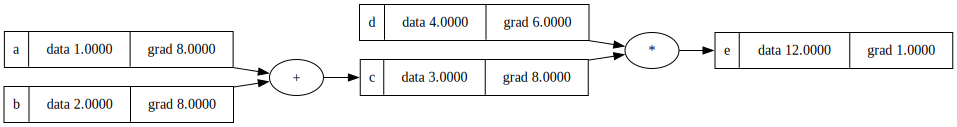

In [5]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(e)
for v in reversed(topo):
    v.grad = 0 # 注意：梯度更新时要先清零

e.backward()
draw_dot(e)